<a href="https://colab.research.google.com/github/RJDom10/Curso-Machine-Learning/blob/main/notebooks/01_preprocesamiento/01_Preprocesamiento_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pre-procesamiento de Datos para Machine Learning

<img src="http://tanukamandal.com/wp-content/uploads/2018/05/data-preparation-1-570x350.png" width="800" align="middle">

**Curso de Machine Learning** | Módulo 1: Preparación de Datos

---

> *"Los datos son el nuevo petróleo, pero como el petróleo, deben ser refinados antes de poder ser utilizados."* — Clive Humby

---

## 📋 Tabla de Contenido

1. [Introducción al Pre-procesamiento de Datos](#1-introduccion)
2. [Carga y Exploración Inicial del Dataset](#2-carga)
3. [Identificación de Datos Faltantes](#3-faltantes)
4. [Representación de Datos No Tabulares](#4-no-tabulares)
5. [Técnicas de Pre-procesamiento](#5-tecnicas)
    - 5.1. Limpieza de Datos
    - 5.2. Normalización de Datos
    - 5.3. Transformación de Datos (Encoding)
    - 5.4. Imputación de Datos Faltantes
    - 5.5. Integración de Datos
    - 5.6. Identificación de Outliers
6. [Reducción de Datos](#6-reduccion)

### 📚 Literatura Recomendada

- García, S., Luengo, J., & Herrera, F. (2015). *Data preprocessing in data mining* (pp. 195-243). Cham, Switzerland: Springer International Publishing.

---

## 1. Introducción al Pre-procesamiento (PP) de Datos <a id="1-introduccion"></a>

El **preprocesamiento** de datos dentro de la Ciencia de Datos es **FUNDAMENTAL**.

Según el Foro Económico Mundial, **¡para 2030 generaremos alrededor de 463 exabytes ($463 \times 10^{18}$ bytes = 463 millones de TB) de datos a nivel mundial por día!** Ante esta magnitud de datos, debemos preguntarnos:

*   ¿Todos los datos son adecuados para ser utilizados por los algoritmos de aprendizaje automático?
*   ¿Cómo decidimos eso?
*   ¿Qué pasos debemos seguir para preparar los datos?

El **preprocesamiento** es el primer paso a realizarse antes de comenzar a entrenar cualquier tipo de modelo, ya que la calidad de los datos y la información útil que puede derivarse de estos **afecta directamente la capacidad de nuestros modelos**.

> 💡 **Punto Clave:** *"Garbage In, Garbage Out"* — Si alimentamos un modelo con datos de mala calidad, obtendremos predicciones de mala calidad, sin importar qué tan sofisticado sea el algoritmo.

<!-- TODO: Agregar imagen del proceso de Data Science -->
<!-- ![Proceso de Data Science](imagen_proceso.png) -->

*Referencia: https://www.kdnuggets.com/2016/03/data-science-process.html*

---

## 2. Carga y Exploración Inicial del Dataset <a id="2-carga"></a>

### Descripción del Dataset: Credit Approval

Utilizaremos un conjunto de datos de **aprobación crediticia** que contiene:

| Característica | Valor |
|----------------|-------|
| **Registros (filas)** | 650 clientes |
| **Variables explicativas** | 15 (nominales/categóricas y numéricas) |
| **Variable objetivo** | `class` (aprobado `+` / rechazado `-`) |
| **Total de columnas** | 16 |

> 🔗 Fuente: [UCI Machine Learning Repository - Credit Approval](https://archive.ics.uci.edu/ml/datasets/Credit+Approval)

### Preguntas para reflexionar antes de iniciar:

> ❓ **¿Una computadora puede analizar directamente variables nominales/categóricas?**

> ❓ **En el caso negativo, ¿cómo podríamos convertir la variable para que la computadora pueda interpretarla?**

> ❓ **¿Qué se debe hacer cuando una variable presenta un dato faltante?**

In [1]:
# ============================================================
# Importación de librerías necesarias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import image as img

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# ============================================================
# Carga del dataset desde GitHub
# ============================================================
url = 'https://raw.githubusercontent.com/RJDom10/Curso-Machine-Learning/refs/heads/main/creditApproval_dataset.csv'
df = pd.read_csv(url)

print(f"📊 Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"   Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
df.head(10)

📊 Dataset cargado exitosamente
   Dimensiones: 690 filas × 16 columnas
   Tamaño en memoria: 429.7 KB



,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.250,t,t,1,f,g,202,0,+
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43,560,+
2,a,24.5,0.500,u,g,q,h,1.500,t,f,0,f,g,280,824,+
3,b,27.83,1.540,u,g,w,v,3.750,t,t,5,t,g,100,3,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120,0,+
5,b,32.08,4.000,u,g,m,v,2.500,t,f,0,t,g,360,0,+
6,b,33.17,1.040,u,g,r,h,6.500,t,f,0,t,g,164,31285,+
7,a,22.92,11.585,u,g,cc,v,0.040,t,f,0,f,g,80,1349,+
8,b,54.42,0.500,y,p,k,h,3.960,t,f,0,f,g,180,314,+
9,b,42.5,4.915,y,p,w,v,3.165,t,f,0,t,g,52,1442,+


In [3]:
# ============================================================
# Exploración rápida del dataset
# ============================================================
print("📋 Información general del dataset:")
print("=" * 50)
print(f"\n🔢 Tipos de datos:")
print(df.dtypes)
print(f"\n📈 Estadísticas descriptivas (variables numéricas):")
df.describe()

📋 Información general del dataset:

🔢 Tipos de datos:
A1        object
A2        object
A3       float64
A4        object
A5        object
A6        object
A7        object
A8       float64
A9        object
A10       object
A11        int64
A12       object
A13       object
A14       object
A15        int64
class     object
dtype: object

📈 Estadísticas descriptivas (variables numéricas):


,A3,A8,A11,A15
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


---

## 3. Identificación de Datos Faltantes <a id="3-faltantes"></a>

Un paso crucial en el preprocesamiento es **identificar si existen datos faltantes** en nuestro dataset. En este caso, los valores faltantes están codificados con el símbolo `'?'` en lugar de `NaN`.

> ⚠️ **Importante:** No todos los datasets usan `NaN` para representar valores faltantes. Es fundamental conocer la convención de cada dataset.

### Método 1: Inspección de valores únicos

Para detectar valores faltantes, podemos revisar los valores únicos de cada columna:

In [ ]:
# ============================================================
# Identificar valores faltantes marcados con '?'
# ============================================================
print("🔍 Buscando valores faltantes ('?') en cada columna:")
print("=" * 50)

for col in df.columns:
    unique_vals = df[col].unique()
    has_missing = '?' in unique_vals
    if has_missing:
        count = (df[col] == '?').sum()
        print(f"  ⚠️  {col}: {count} valores faltantes ({count/len(df)*100:.1f}%)")

print()
print("📊 Ejemplo - Valores únicos de A4:", df.A4.unique())
print("📊 Ejemplo - Valores únicos de A5:", df.A5.unique())

### Método 2: Función `which()` (inspirada en R)

En R existe una función nativa llamada `which()` que devuelve los índices donde se cumple una condición. Podemos crear nuestra propia versión en Python:

In [ ]:
# ============================================================
# Función which() - Inspirada en R
# ============================================================
def which(iterable):
    """
    Devuelve los índices donde la condición es True.
    Equivalente a la función which() de R.
    
    Parámetros:
        iterable: Un iterable de valores booleanos
    
    Retorna:
        Lista de índices donde el valor es True
    """
    try:
        items = list(iter(iterable))
    except TypeError as e:
        raise Exception(f"'which' solo puede aplicarse a iterables. {str(e)}")
    return [i for i, x in enumerate(items) if bool(x)]

# Encontrar los índices donde A4 tiene valores faltantes
indices_faltantes = which(df.A4 == '?')
print(f"📍 Índices con valores faltantes en A4: {indices_faltantes}")
print(f"   Total: {len(indices_faltantes)} registros")

In [ ]:
# ============================================================
# Visualizar los registros con datos faltantes usando which()
# ============================================================
ixes = which(df.A4 == '?')
df.iloc[ixes, :]

### Método 3: Filtrado directo con Pandas (recomendado)

Sin embargo, **Pandas ofrece una forma mucho más pythónica y legible** de realizar el mismo filtrado:

In [ ]:
# ============================================================
# Filtrado directo con Pandas - Más limpio y legible
# ============================================================
df[df['A4'] == '?']

---

## 4. Representación de Datos No Tabulares <a id="4-no-tabulares"></a>

Si bien mucha información se encuentra en formato tabular, **no siempre es el caso**. Los datos pueden tener muchas formas diferentes:
- 📊 Tablas estructuradas
- 🖼️ Imágenes
- 🎵 Archivos de audio
- 🎬 Videos
- 📝 Texto no estructurado

Las máquinas **no entienden** los datos de texto, imagen o video **tal como son**. Solo entienden números (1s y 0s). Por lo tanto, necesitamos **transformar** estos datos a una representación numérica.

![ML Comic](https://imgs.xkcd.com/comics/machine_learning.png)

### Ejemplo: ¿Cómo representamos una imagen para que una máquina la entienda?

Una imagen se representa como un **tensor** (array multidimensional) de valores numéricos correspondientes a los canales de color **RGB** (Rojo, Verde, Azul). Cada imagen corresponde a 3 matrices $z_i \in Z$, de tamaño $m \times n$.

In [4]:
# ============================================================
# Representación numérica de una imagen
# ============================================================
# Nota: La imagen 'Ds5Rc.png' debe estar en el directorio de trabajo
try:
    image = img.imread("Ds5Rc.png")
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    # Imagen original
    axes[0].imshow(image)
    axes[0].set_title("Imagen Original (RGB)", fontweight='bold')
    axes[0].axis('off')
    
    # Canal Rojo
    axes[1].imshow(image[:,:,0], cmap='Reds')
    axes[1].set_title("Canal Rojo (R)", fontweight='bold')
    axes[1].axis('off')
    
    # Canal Verde
    axes[2].imshow(image[:,:,1], cmap='Greens')
    axes[2].set_title("Canal Verde (G)", fontweight='bold')
    axes[2].axis('off')
    
    # Canal Azul
    axes[3].imshow(image[:,:,2], cmap='Blues')
    axes[3].set_title("Canal Azul (B)", fontweight='bold')
    axes[3].axis('off')
    
    plt.suptitle("Descomposición de una imagen en canales RGB", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n📐 Tipo del objeto: {type(image)}")
    print(f"📐 Dimensiones (alto × ancho × canales): {image.shape}")
    print(f"📐 Total de valores numéricos: {image.size:,}")
except FileNotFoundError:
    print("⚠️ La imagen 'Ds5Rc.png' no se encontró. Colócala en el directorio de trabajo.")

⚠️ La imagen 'Ds5Rc.png' no se encontró. Colócala en el directorio de trabajo.


---

## 5. Técnicas de Pre-procesamiento <a id="5-tecnicas"></a>

> 💡 En cualquier proceso de Machine Learning, **el PP es el paso en el que los datos se transforman o codifican** para llevarlos a un estado tal que la máquina pueda analizarlos fácilmente.

### Tipos de problemas y técnicas de PP:

| Problema | Técnica | Descripción |
|----------|---------|-------------|
| ¿Cómo limpio los datos? | **Limpieza de datos** | Corrección, filtrado y reducción de detalles |
| ¿Cómo unifico y escalo los datos? | **Normalización** | Escalado a rangos estándar |
| ¿Cómo proporciono datos precisos? | **Transformación** | Encoding, discretización |
| ¿Cómo manejo los datos faltantes? | **Imputación** | Estimación de valores perdidos |
| ¿Cómo incorporo y ajusto datos? | **Integración** | Fusión de múltiples fuentes |
| ¿Cómo detecto y manejo el ruido? | **Análisis de outliers** | Identificación de anomalías |

<!-- TODO: Agregar imagen del diagrama de técnicas de PP -->
<!-- ![Técnicas de PP](imagen_tecnicas.png) -->

---

### 5.1. Limpieza de Datos

La limpieza de datos involucra operaciones como:
-  **Corrección** de datos erróneos
-  **Filtrado** de datos específicos o incorrectos
-  **Reducción** de detalles innecesarios
-  **Detección de discrepancias** y datos sucios

>  **Nota:** La limpieza de datos típicamente requiere **intervención humana** ya que es necesaria la comprensión del dominio de los datos.

#### Ejemplo práctico: Filtrado de datos

<!-- TODO: Agregar imagen del dataset UCI Credit Approval -->
<!-- ![UCI Credit Approval](imagen_uci.png) -->

*Fuente: https://archive.ics.uci.edu/ml/datasets/Credit+Approval*

In [5]:
# ============================================================
# 5.1.1 Filtrado de datos por condición
# ============================================================

# Recargar datos limpios
url = 'https://raw.githubusercontent.com/RJDom10/Curso-Machine-Learning/refs/heads/main/creditApproval_dataset.csv'
df = pd.read_csv(url)

# Ejemplo 1: Remover registros donde A4 == 'u'
print(" Valores únicos de A4 (original):", df.A4.unique())

df1 = df[df['A4'] != 'u']
print(" Valores únicos de A4 (sin 'u'):", df1.A4.unique())
print(f"   Registros removidos: {len(df) - len(df1)}")

 Valores únicos de A4 (original): ['u' 'y' '?' 'l']
 Valores únicos de A4 (sin 'u'): ['y' '?' 'l']
   Registros removidos: 519


In [6]:
# ============================================================
# 5.1.2 Filtrado por rango de valores numéricos
# ============================================================

# Acotar la variable A3 al rango (4, 10)
df2 = df[(df['A3'] > 4) & (df['A3'] < 10)]

print(f" Registros originales: {len(df)}")
print(f" Registros con A3 entre 4 y 10: {len(df2)}")
print(f"   Rango A3 original: [{df.A3.min()}, {df.A3.max()}]")
print(f"   Rango A3 filtrado: [{df2.A3.min()}, {df2.A3.max()}]")
print()
df2.head(7)

 Registros originales: 690
 Registros con A3 entre 4 y 10: 150
   Rango A3 original: [0.0, 28.0]
   Rango A3 filtrado: [4.04, 9.96]



,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43,560,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120,0,+
9,b,42.5,4.915,y,p,w,v,3.165,t,f,0,t,g,52,1442,+
12,a,38.25,6.000,u,g,k,v,1.000,t,f,0,t,g,0,0,+
13,b,48.08,6.040,u,g,k,v,0.040,f,f,0,f,g,0,2690,+
15,b,36.67,4.415,y,p,k,v,0.250,t,t,10,t,g,320,0,+
17,a,23.25,5.875,u,g,q,v,3.170,t,t,10,f,g,120,245,+


In [7]:
# ============================================================
# 5.1.3 Reemplazo de valores en columnas
# ============================================================

# Reemplazar los valores de la variable 'class' (+ y -) por números (1 y -1)
df3 = df.copy()
df3 = df3.replace({"class": {"+": 1, "-": -1}})

print(" Valores originales de 'class':", df['class'].unique())
print(" Valores nuevos de 'class':", df3['class'].unique())
print()
df3.head()

 Valores originales de 'class': ['+' '-']
 Valores nuevos de 'class': [ 1 -1]



C:\Users\HP\AppData\Local\Temp\ipykernel_8512\893942121.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3 = df3.replace({"class": {"+": 1, "-": -1}})


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43,560,1
2,a,24.5,0.500,u,g,q,h,1.50,t,f,0,f,g,280,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120,0,1


---

### 5.2. Normalización de Datos

La normalización escala los valores numéricos a un **rango estándar**. Esto es crucial porque:

1. Los algoritmos de ML son sensibles a la **magnitud** de las variables
2. Variables con rangos muy diferentes pueden **dominar** el aprendizaje
3. Mejora la **convergencia** de algoritmos de optimización

#### Métodos comunes de normalización:

| Método | Fórmula | Rango |
|--------|---------|-------|
| **Min-Max** | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | [0, 1] |
| **Min-Max escalado** | $x' = 2 \cdot \frac{x - x_{min}}{x_{max} - x_{min}} - 1$ | [-1, 1] |
| **Z-Score** | $x' = \frac{x - \mu}{\sigma}$ | ~ [-3, 3] |

In [ ]:
# ============================================================
# 5.2.1 Normalización Min-Max manual
# ============================================================

# Normalización de la variable A8 al rango [-1, 1]
x_new = 2 * ((df.A8 - df.A8.min()) / (df.A8.max() - df.A8.min())) - 1

print("📊 Variable A8 - Antes de normalizar:")
print(f"   Min: {df.A8.min():.3f}, Max: {df.A8.max():.3f}, Media: {df.A8.mean():.3f}")
print()
print("📊 Variable A8 - Después de normalizar [-1, 1]:")
print(f"   Min: {x_new.min():.3f}, Max: {x_new.max():.3f}, Media: {x_new.mean():.3f}")

In [8]:
# ============================================================
# 5.2.2 Normalización con scikit-learn
# ============================================================
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df_scaled = df.copy()

# Seleccionar solo columnas numéricas
numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()
print(f" Columnas numéricas a normalizar: {numeric_cols}")

# Min-Max Scaling [0, 1]
scaler_minmax = MinMaxScaler()
df_scaled[numeric_cols] = scaler_minmax.fit_transform(df_scaled[numeric_cols])

print("\n Después de Min-Max Scaling:")
df_scaled[numeric_cols].describe().round(3)

 Columnas numéricas a normalizar: ['A3', 'A8', 'A11', 'A15']

 Después de Min-Max Scaling:


,A3,A8,A11,A15
count,690.000,690.000,690.000,690.000
mean,0.170,0.078,0.036,0.010
std,0.178,0.117,0.073,0.052
min,0.000,0.000,0.000,0.000
25%,0.036,0.006,0.000,0.000
50%,0.098,0.035,0.000,0.000
75%,0.257,0.092,0.045,0.004
max,1.000,1.000,1.000,1.000


#### 📝 Ejercicio: Normalización Z-Score

Aplica la normalización Z-Score (StandardScaler de scikit-learn) a las columnas numéricas del dataset y compara los resultados con Min-Max.

In [ ]:
# ============================================================
# EJERCICIO: Normalización Z-Score
# ============================================================

# Tu código aquí:
# 1. Crea una copia del DataFrame original
# 2. Aplica StandardScaler a las columnas numéricas
# 3. Muestra las estadísticas descriptivas

# df_zscore = df.copy()
# scaler_zscore = StandardScaler()
# ...


---

### 5.3. Transformación de Datos (Encoding)

Los algoritmos de ML generalmente necesitan **datos numéricos**. Las variables categóricas deben transformarse a representaciones numéricas.

#### Principales técnicas de encoding:

| Técnica | Descripción | Ejemplo |
|---------|-------------|---------|
| **Label Encoding** | Asigna un número entero a cada categoría | `{u: 1, y: 2, l: 3}` |
| **One-Hot Encoding** | Crea columnas binarias para cada categoría | `A4_u: [1,0,0]`, `A4_y: [0,1,0]` |
| **Category Codes** | Usa el tipo `Categorical` de Pandas | Automático |

>  **Cuidado con Label Encoding:** Puede introducir un orden artificial entre categorías que realmente no tienen orden. Usa **One-Hot Encoding** para variables nominales (sin orden inherente).

#### 5.3.1 One-Hot Encoding

Transforma cada valor categórico en una nueva columna binaria (0 o 1):

In [9]:
# ============================================================
# 5.3.1 One-Hot Encoding con pandas
# ============================================================

# Recargar datos
url = 'https://raw.githubusercontent.com/RJDom10/Curso-Machine-Learning/refs/heads/main/creditApproval_dataset.csv'
df = pd.read_csv(url)

# One-Hot Encoding de la variable A4
print(" Valores originales de A4:", sorted(df.A4.unique()))
print()

# Método con pandas - get_dummies
df_encoded = pd.get_dummies(df, columns=['A4'], prefix='A4', dtype=int)
print(" Nuevas columnas creadas:")
a4_cols = [col for col in df_encoded.columns if col.startswith('A4_')]
print(f"   {a4_cols}")
print()
df_encoded[['A1', 'A2', 'A3'] + a4_cols].head(10)

 Valores originales de A4: ['?', 'l', 'u', 'y']

 Nuevas columnas creadas:
   ['A4_?', 'A4_l', 'A4_u', 'A4_y']



,A1,A2,A3,A4_?,A4_l,A4_u,A4_y
0,b,30.83,0.000,0,0,1,0
1,a,58.67,4.460,0,0,1,0
2,a,24.5,0.500,0,0,1,0
3,b,27.83,1.540,0,0,1,0
4,b,20.17,5.625,0,0,1,0
5,b,32.08,4.000,0,0,1,0
6,b,33.17,1.040,0,0,1,0
7,a,22.92,11.585,0,0,1,0
8,b,54.42,0.500,0,0,0,1
9,b,42.5,4.915,0,0,0,1


#### 5.3.2 Reemplazo de símbolos por números (Label Encoding manual)

En algunos casos simples, podemos reemplazar categorías por números usando un diccionario de mapeo:

In [10]:
# ============================================================
# 5.3.2 Label Encoding manual con replace()
# ============================================================

# Recargar datos
url = 'https://raw.githubusercontent.com/RJDom10/Curso-Machine-Learning/refs/heads/main/creditApproval_dataset.csv'
df = pd.read_csv(url)

# Definir el mapeo de reemplazo
reemplazos = {"A4": {"u": 1, "y": 2, "?": np.nan, "l": 3}}

print(" Antes del reemplazo:")
print(f"   Valores únicos de A4: {sorted(df.A4.unique())}")

# Aplicar reemplazos
df_copy = df.copy()
df_copy = df_copy.replace(reemplazos)

print("\n Después del reemplazo:")
print(f"   Valores únicos de A4: {sorted(df_copy.A4.dropna().unique())}")
print(f"   Valores NaN en A4: {df_copy.A4.isna().sum()}")

# Mostrar las filas que originalmente tenían '?'
print("\n Filas que tenían '?' (ahora NaN):")
df_copy[df.A4 == '?']

 Antes del reemplazo:
   Valores únicos de A4: ['?', 'l', 'u', 'y']

 Después del reemplazo:
   Valores únicos de A4: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
   Valores NaN en A4: 6

 Filas que tenían '?' (ahora NaN):


C:\Users\HP\AppData\Local\Temp\ipykernel_8512\1682721150.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy = df_copy.replace(reemplazos)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,class
206,a,71.58,0.0,NaN,?,?,?,0.0,f,f,0,f,p,?,0,+
270,b,37.58,0.0,NaN,?,?,?,0.0,f,f,0,f,p,?,0,+
330,b,20.42,0.0,NaN,?,?,?,0.0,f,f,0,f,p,?,0,-
456,b,34.58,0.0,NaN,?,?,?,0.0,f,f,0,f,p,?,0,-
592,b,23.17,0.0,NaN,?,?,?,0.0,f,f,0,f,p,?,0,+
622,a,25.58,0.0,NaN,?,?,?,0.0,f,f,0,f,p,?,0,+


#### 5.3.3 Category Codes de Pandas

Otra forma automática de convertir categorías a números es usar el tipo `Categorical` de Pandas:

In [11]:
# ============================================================
# 5.3.3 Codificación automática con pandas Categorical
# ============================================================
df_copy = df.copy()
df_copy['A4'] = df_copy['A4'].astype('category')
df_copy['A4_codigo'] = df_copy['A4'].cat.codes

print(" Mapeo automático de categorías:")
for cat, code in zip(df_copy['A4'].cat.categories, range(len(df_copy['A4'].cat.categories))):
    print(f"   '{cat}' → {code}")

print()
df_copy[['A4', 'A4_codigo']].head(10)

 Mapeo automático de categorías:
   '?' → 0
   'l' → 1
   'u' → 2
   'y' → 3



,A4,A4_codigo
0,u,2
1,u,2
2,u,2
3,u,2
4,u,2
5,u,2
6,u,2
7,u,2
8,y,3
9,y,3


#### 5.3.4 Discretización: De números a categorías

¿Y cómo hacemos el proceso inverso? Podemos **discretizar** variables continuas usando percentiles con `pd.qcut()`:

In [12]:
# ============================================================
# 5.3.4 Discretización con qcut()
# ============================================================

# Segmentar la variable A3 en 5 grupos (quintiles)
bins = pd.qcut(df['A3'], q=5)
codes = pd.qcut(df['A3'], q=5).astype('category').cat.codes

print(" Discretización de A3 en 5 quintiles:")
print(f"   Rango original: [{df['A3'].min()}, {df['A3'].max()}]")
print(f"   Intervalos creados:")
for interval in sorted(bins.unique()):
    count = (bins == interval).sum()
    print(f"   {interval}: {count} registros")

print("\n Pregunta: ¿Los rangos de cada intervalo son equidistantes?")
print("   Respuesta: No necesariamente. qcut() divide por CANTIDAD de observaciones,")
print("   no por el rango de valores. Cada grupo tiene ~igual número de registros.")

 Discretización de A3 en 5 quintiles:
   Rango original: [0.0, 28.0]
   Intervalos creados:
   (-0.001, 0.75]: 144 registros
   (0.75, 1.934]: 132 registros
   (1.934, 4.016]: 138 registros
   (4.016, 9.432]: 138 registros
   (9.432, 28.0]: 138 registros

 Pregunta: ¿Los rangos de cada intervalo son equidistantes?
   Respuesta: No necesariamente. qcut() divide por CANTIDAD de observaciones,
   no por el rango de valores. Cada grupo tiene ~igual número de registros.


---

### 5.4. Imputación de Datos Faltantes

El propósito es llenar las variables que contienen **valores faltantes** (*missing values*) con estimaciones razonables.

> **Punto Clave:** En la mayoría de los casos, es mejor agregar una estimación razonable de un valor que dejarlo en blanco, ya que muchos algoritmos de ML no manejan valores `NaN`.

<!-- TODO: Agregar imagen de patrones de datos faltantes -->
<!-- ![Patrones de Datos Faltantes](imagen_missing.png) -->

*Referencia: https://stefvanbuuren.name/fimd/missing-data-pattern.html*

#### Estrategias de imputación:

| Tipo de dato | Estrategia | Descripción |
|-------------|-----------|-------------|
| **Numérico** | `mean` | Reemplaza con la media |
| **Numérico** | `median` | Reemplaza con la mediana (robusto a outliers) |
| **Categórico** | `most_frequent` | Reemplaza con la moda (valor más frecuente) |
| **Cualquiera** | `constant` | Reemplaza con un valor fijo |

In [13]:
# ============================================================
# 5.4.1 Crear datos faltantes artificiales (para demostración)
# ============================================================
import random

# Recargar datos
url = 'https://raw.githubusercontent.com/RJDom10/Curso-Machine-Learning/refs/heads/main/creditApproval_dataset.csv'
df = pd.read_csv(url)

# Insertar 20% de NaN artificialmente
random.seed(3)
df_missing = df.copy()

for col in df_missing.columns:
    df_missing.loc[df_missing.sample(frac=0.2).index, col] = np.nan

print("Porcentaje de datos faltantes por columna:")
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).round(1)
print(missing_pct.to_string())
print(f"\n Total de celdas faltantes: {df_missing.isnull().sum().sum()} de {df_missing.size}")

Porcentaje de datos faltantes por columna:
A1       20.0
A2       20.0
A3       20.0
A4       20.0
A5       20.0
A6       20.0
A7       20.0
A8       20.0
A9       20.0
A10      20.0
A11      20.0
A12      20.0
A13      20.0
A14      20.0
A15      20.0
class    20.0

 Total de celdas faltantes: 2208 de 11040


In [14]:
# ============================================================
# 5.4.2 Imputación de variables NUMÉRICAS (media/mediana)
# ============================================================
from sklearn.impute import SimpleImputer

# Imputar A3 y A8 con la MEDIANA (más robusta a outliers que la media)
imp_median = SimpleImputer(missing_values=np.nan, strategy='median')
imp_median.fit(df_missing.loc[:, ['A3', 'A8']])

df_imputed = df_missing.copy()
df_imputed.loc[:, ['A3', 'A8']] = imp_median.transform(df_missing.loc[:, ['A3', 'A8']])

print(" Antes de imputar:")
print(f"   NaN en A3: {df_missing['A3'].isna().sum()}")
print(f"   NaN en A8: {df_missing['A8'].isna().sum()}")
print(f"\n Después de imputar (mediana):")
print(f"   NaN en A3: {df_imputed['A3'].isna().sum()}")
print(f"   NaN en A8: {df_imputed['A8'].isna().sum()}")
print(f"\n Valores de mediana utilizados:")
print(f"   Mediana A3: {imp_median.statistics_[0]:.3f}")
print(f"   Mediana A8: {imp_median.statistics_[1]:.3f}")

 Antes de imputar:
   NaN en A3: 138
   NaN en A8: 138

 Después de imputar (mediana):
   NaN en A3: 0
   NaN en A8: 0

 Valores de mediana utilizados:
   Mediana A3: 2.792
   Mediana A8: 1.000


In [15]:
# ============================================================
# 5.4.3 Imputación de variables CATEGÓRICAS (moda)
# ============================================================
from sklearn.impute import SimpleImputer

imp_category = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imp_category.fit(df_missing.loc[:, ['A1', 'A4']])

df_imputed.loc[:, ['A1', 'A4']] = imp_category.transform(df_missing.loc[:, ['A1', 'A4']])

print(" Antes de imputar:")
print(f"   NaN en A1: {df_missing['A1'].isna().sum()}")
print(f"   NaN en A4: {df_missing['A4'].isna().sum()}")
print(f"\n Después de imputar (moda):")
print(f"   NaN en A1: {df_imputed['A1'].isna().sum()}")
print(f"   NaN en A4: {df_imputed['A4'].isna().sum()}")
print(f"\n Valores más frecuentes utilizados:")
print(f"   Moda A1: '{imp_category.statistics_[0]}'")
print(f"   Moda A4: '{imp_category.statistics_[1]}'")

 Antes de imputar:
   NaN en A1: 138
   NaN en A4: 138

 Después de imputar (moda):
   NaN en A1: 0
   NaN en A4: 0

 Valores más frecuentes utilizados:
   Moda A1: 'b'
   Moda A4: 'u'


---

### 5.5. Integración de Datos

La integración de datos comprende la **fusión de datos de múltiples fuentes**. Este proceso debe realizarse con cuidado para evitar redundancias e inconsistencias.

#### Operaciones típicas:
-  **Identificación** y **unificación** de variables y dominios
-  **Análisis de correlación** entre atributos
-  **Identificación de duplicación** y detección de conflictos

#### Herramienta clave: `pivot_table()`

La función `pivot_table()` de Pandas permite reorganizar y agregar datos de formas muy flexibles.

In [16]:
# ============================================================
# 5.5.1 Ejemplo de pivot_table
# ============================================================

# Recargar datos originales
url = 'https://raw.githubusercontent.com/RJDom10/Curso-Machine-Learning/refs/heads/main/creditApproval_dataset.csv'
df = pd.read_csv(url)

# Crear tabla pivote: promedio de A3 por cada valor de A4 y class
pivot = df.pivot_table(
    index=['A4'],
    columns=['class'],
    values=['A3', 'A8'],
    aggfunc=np.mean
).round(3)

print(" Tabla Pivote: Promedio de A3 y A8 por categoría A4 y clase")
pivot

 Tabla Pivote: Promedio de A3 y A8 por categoría A4 y clase


C:\Users\HP\AppData\Local\Temp\ipykernel_8512\1700895742.py:10: FutureWarning: The provided callable <function mean at 0x0000029468D42480> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = df.pivot_table(


A3           A8       
class       +     -      +      -
A4                               
?       0.000  0.00  0.000  0.000
l      11.188   NaN  5.000    NaN
u       6.220  3.86  3.627  1.169
y       4.400  3.86  2.528  1.477

---

### 5.6. Identificación de Datos Anómalos (Outliers)

El objetivo es detectar **errores aleatorios** o **variaciones extremas** en las variables. Es importante distinguir entre:

- **Identificar** outliers (detectarlos)
- **Eliminar** outliers (no siempre recomendable)

>  **Cuidado:** Un outlier no siempre es un error. Puede ser un dato valioso que representa un caso extremo real.

<!-- TODO: Agregar imágenes de outliers -->
<!-- ![Outliers](imagen_outliers.png) -->

#### Métodos comunes de detección:

| Método | Descripción |
|--------|-------------|
| **IQR (Rango Intercuartílico)** | Valores fuera de Q1 - 1.5×IQR y Q3 + 1.5×IQR |
| **Z-Score** | Valores a más de 2-3 desviaciones estándar |
| **Visualización** | Box plots, scatter plots |

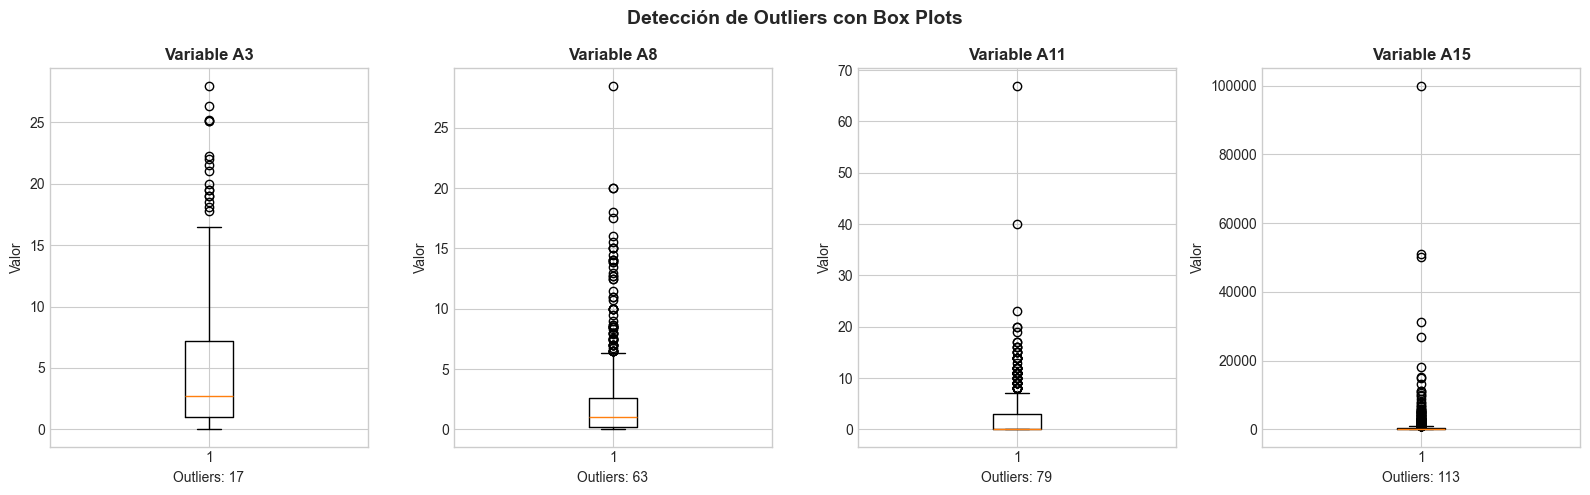

In [17]:
# ============================================================
# 5.6.1 Detección de outliers con visualización
# ============================================================

# Recargar datos
url = 'https://raw.githubusercontent.com/RJDom10/Curso-Machine-Learning/refs/heads/main/creditApproval_dataset.csv'
df = pd.read_csv(url)

# Seleccionar columnas numéricas para analizar
numeric_cols = ['A3', 'A8', 'A11', 'A15']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(f'Variable {col}', fontweight='bold')
    axes[i].set_ylabel('Valor')
    
    # Calcular estadísticas
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    axes[i].set_xlabel(f'Outliers: {len(outliers)}')

plt.suptitle('Detección de Outliers con Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 6. Reducción de Datos <a id="6-reduccion"></a>

La **reducción de datos** comprende el conjunto de técnicas que obtienen una representación reducida de los datos originales.

### Objetivo

Encontrar un sub-conjunto $C'$ que se aproxime al conjunto original $C$ tal que la información contenida en $C' \approx C$.

Esto típicamente significa que se mantiene la **estructura esencial** de los datos originales ($C$), pero la **cantidad de datos es significativamente menor**.

#### Técnicas principales:

| Técnica | Descripción |
|---------|-------------|
| **PCA** | Análisis de Componentes Principales - reduce dimensionalidad |
| **Selección de características** | Elimina variables irrelevantes o redundantes |
| **Muestreo** | Selecciona un subconjunto representativo |
| **Compresión** | Codificación más eficiente de los datos |

---

## Resumen

En este notebook aprendimos los fundamentos del **preprocesamiento de datos**, un paso **imprescindible** antes de aplicar cualquier algoritmo de Machine Learning.

### Puntos clave:

1. ✅ **Garbage In, Garbage Out** — La calidad de los datos determina la calidad del modelo
2. ✅ **Identificar datos faltantes** es el primer paso del análisis
3. ✅ **Normalizar** los datos para que todas las variables tengan la misma escala
4. ✅ **Transformar** variables categóricas a numéricas (One-Hot, Label Encoding)
5. ✅ **Imputar** valores faltantes con estrategias apropiadas (media, mediana, moda)
6. ✅ **Integrar** datos de múltiples fuentes con cuidado
7. ✅ **Detectar outliers** pero no siempre eliminarlos

### Próximos pasos:

- 🔜 Exploración visual de datos (histogramas, scatter plots, joyplots)
- 🔜 Feature Engineering avanzado
- 🔜 Selección de características para ML

---

*Notebook creado para el Curso de Machine Learning*